In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

In [2]:
data = pd.read_csv(PROJECT_ROOT / "data/raw/hvac_training_dataset.csv")
data.head()

,building_type,climate_zone,budget_level,area_sqft,floors,ceiling_height,occupancy,operating_hours,building_age,outdoor_temp,humidity,insulation,glass_ratio,recommended_hvac
0,Residential,Humid,Medium,1021.68,1.0,8.47,12.0,13.0,26.0,33.09,80.72,Average,Low,Split AC
1,Residential,Humid,Medium,2091.91,1.0,9.35,35.0,9.0,6.0,30.87,84.94,Good,Low,Split AC
2,Residential,Humid,Medium,2316.93,1.0,8.27,25.0,7.0,13.0,33.39,89.19,Average,Low,Split AC
3,Residential,Hot,NaN,2451.41,1.0,9.82,58.0,12.0,18.0,33.57,28.04,Average,Low,Split AC
4,Retail,Warm,Medium,119190.52,5.0,16.12,12825.0,14.0,0.0,30.76,51.36,Good,High,VRF


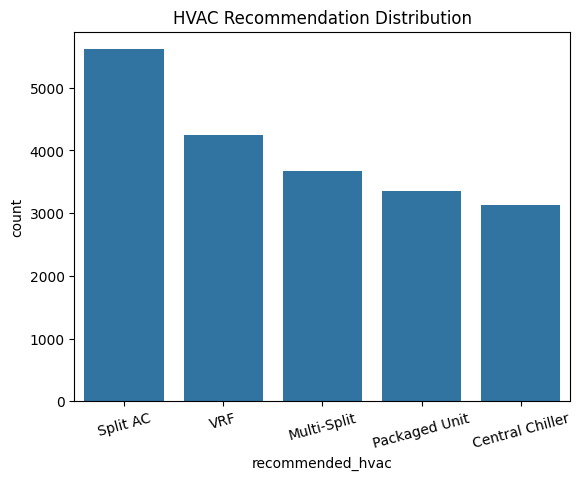

In [3]:
sns.countplot(
    data=data,
    x="recommended_hvac",
    order=data["recommended_hvac"].value_counts().index
)

plt.title("HVAC Recommendation Distribution")
plt.xticks(rotation=15)
plt.show()

In [4]:
model_df = data

In [5]:
model_df.isna().sum()

building_type       380
climate_zone        397
budget_level        384
area_sqft           380
floors              391
ceiling_height      400
occupancy           450
operating_hours     375
building_age        411
outdoor_temp        397
humidity            444
insulation          400
glass_ratio         367
recommended_hvac      0
dtype: int64

In [6]:
print(model_df["recommended_hvac"].value_counts(normalize=True) * 100)

recommended_hvac
Split AC           28.065
VRF                21.210
Multi-Split        18.340
Packaged Unit      16.755
Central Chiller    15.630
Name: proportion, dtype: float64


In [7]:
missing = (
    model_df.isnull().mean().sort_values(ascending=False) * 100
)

print(missing)

occupancy           2.250
humidity            2.220
building_age        2.055
insulation          2.000
ceiling_height      2.000
climate_zone        1.985
outdoor_temp        1.985
floors              1.955
budget_level        1.920
building_type       1.900
area_sqft           1.900
operating_hours     1.875
glass_ratio         1.835
recommended_hvac    0.000
dtype: float64


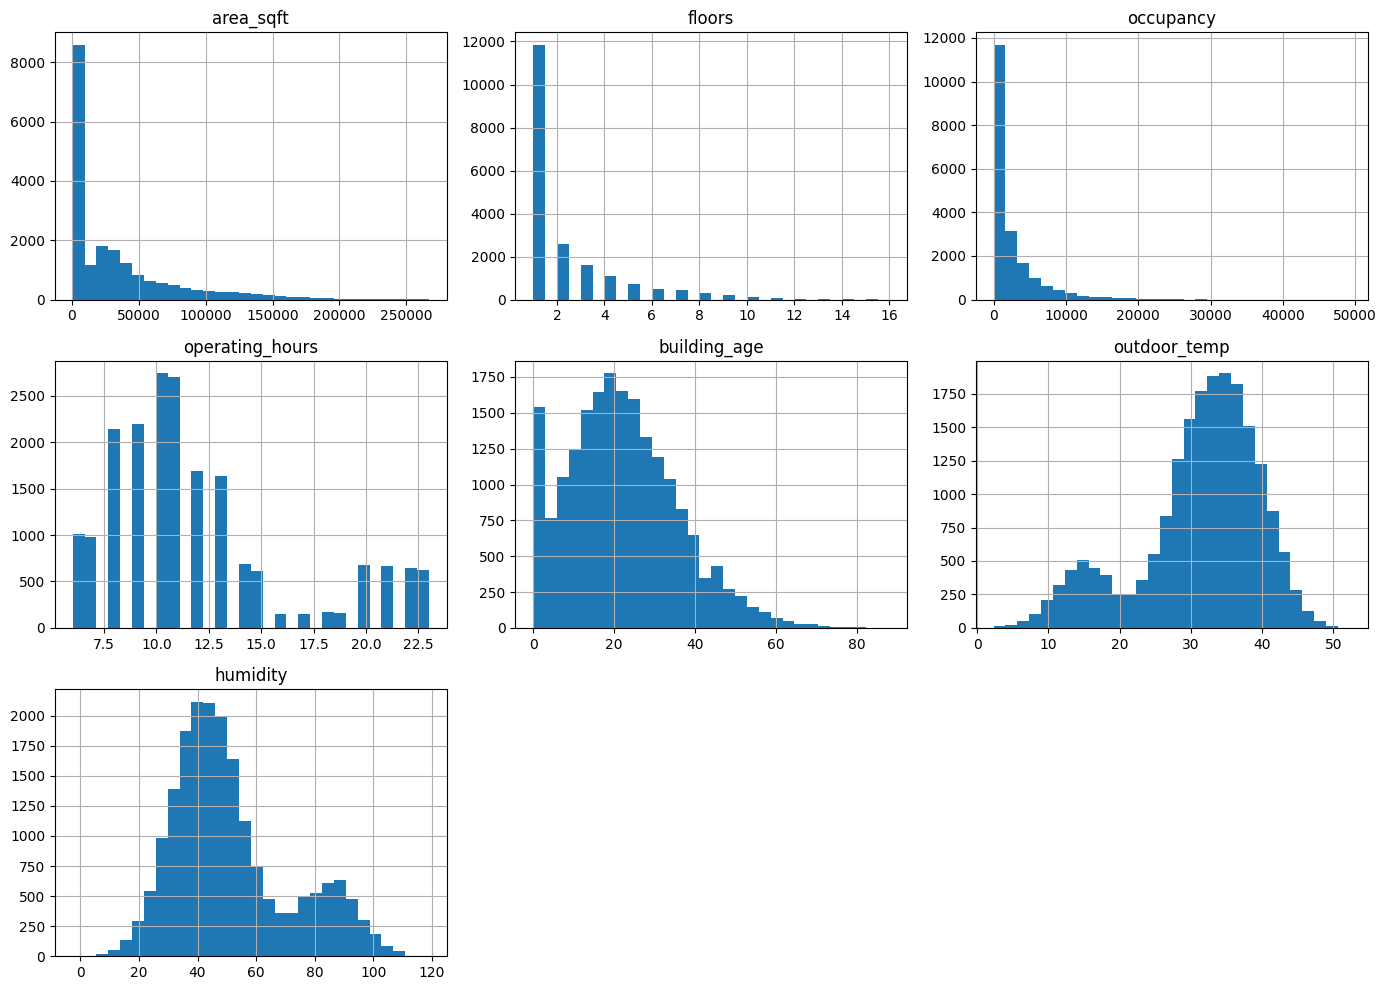

In [8]:
numerical_cols = [
    "area_sqft",
    "floors",
    "occupancy",
    "operating_hours",
    "building_age",
    "outdoor_temp",
    "humidity"
]

model_df[numerical_cols].hist(
    figsize=(14,10),
    bins=30
)

plt.tight_layout()

plt.show()

In [9]:
categorical_cols = [
    "building_type",
    "climate_zone",
    "budget_level",
    "insulation",
    "glass_ratio"
]

for col in categorical_cols:

    print("\n", col)

    print(model_df[col].value_counts(normalize=True))


 building_type
building_type
Residential    0.402446
Office         0.249541
Retail         0.151580
Hospital       0.101172
Industrial     0.095260
Name: proportion, dtype: float64

 climate_zone
climate_zone
Hot      0.355201
Warm     0.297199
Humid    0.197980
Cold     0.149620
Name: proportion, dtype: float64

 budget_level
budget_level
Medium    0.457739
Low       0.340181
High      0.202080
Name: proportion, dtype: float64

 insulation
insulation
Average      0.399847
Poor         0.287602
Good         0.254082
Excellent    0.058469
Name: proportion, dtype: float64

 glass_ratio
glass_ratio
Low       0.420262
Medium    0.356084
High      0.223654
Name: proportion, dtype: float64


In [10]:
pd.crosstab(
    model_df["building_type"],
    model_df["recommended_hvac"],
    normalize="index"
)

recommended_hvac,Central Chiller,Multi-Split,Packaged Unit,Split AC,VRF
building_type,,,,,
Hospital,0.858942,0.021662,0.029219,0.004534,0.085642
Industrial,0.233280,0.044409,0.522739,0.011771,0.187801
Office,0.077410,0.286152,0.127859,0.054739,0.453840
Residential,0.032675,0.236702,0.042553,0.647543,0.040527
Retail,0.098184,0.069267,0.434768,0.028245,0.369536


In [11]:
pd.crosstab(
    model_df["budget_level"],
    model_df["recommended_hvac"],
    normalize="index"
)

recommended_hvac,Central Chiller,Multi-Split,Packaged Unit,Split AC,VRF
budget_level,,,,,
High,0.187437,0.157669,0.107215,0.246973,0.300706
Low,0.155103,0.133973,0.140866,0.358909,0.211149
Medium,0.143669,0.230204,0.214389,0.237554,0.174184


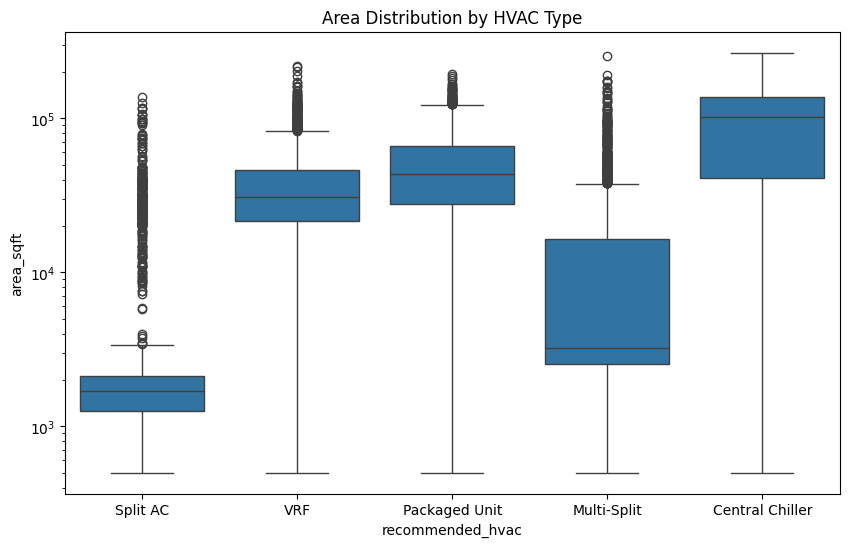

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=model_df,
    x="recommended_hvac",
    y="area_sqft"
)

plt.yscale("log")

plt.title("Area Distribution by HVAC Type")

plt.show()

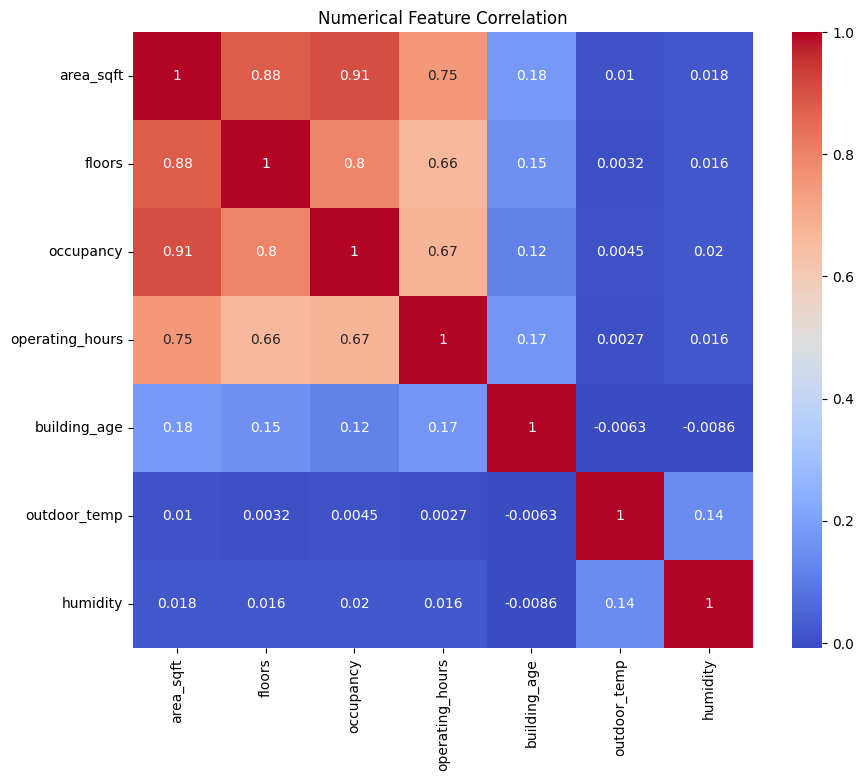

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    model_df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Numerical Feature Correlation")

plt.show()